# Exploratory Data Analysis

This notebook contains the preprocessing and initial analysis of the exoplanet dataset.

The goal is to better understand the structure of the data and identify potential patterns, especially regarding Earth-like planets.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

## Dataset Description

The dataset contains information about discovered exoplanets. Each row corresponds to a planet and includes physical and orbital characteristics.

Some important features include:

- `pl_name`: name of the exoplanet  
- `pl_rade`: radius of the planet (in Earth radii)  
- `pl_bmasse`: mass of the planet (in Earth masses)  
- `pl_eqt`: equilibrium temperature of the planet (in Kelvin)  
- `pl_orbper`: orbital period (in days)  

These features are particularly relevant for identifying Earth-like planets and studying their properties.

In [23]:
df = pd.read_csv("data/PS_2026.03.20_03.49.15.csv", comment="#")

df.head()

,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_controv_flag,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,AU Mic b,AU Mic,1,1,4,Transit,2020.0,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.100,4.529,0.020,-0.020,7.84038,0.000731,-0.000731,2026-03-05,2024-09,2026-03-05
1,AU Mic c,AU Mic,1,1,4,Transit,2021.0,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.100,4.529,0.020,-0.020,7.84038,0.000731,-0.000731,2026-03-05,2024-09,2026-03-05
2,BD+05 4868 A b,BD+05 4868 A,1,2,1,Transit,2025.0,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.010,7.448,0.026,-0.026,9.84152,0.000476,-0.000476,2025-03-21,2025-01,2025-03-21
3,BD-14 3065 b,BD-14 3065 A,1,3,1,Transit,2024.0,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.013,9.932,0.026,-0.026,10.91000,0.001617,-0.001617,2024-06-25,2024-03,2024-06-25
4,DS Tuc A b,DS Tuc A,1,2,1,Transit,2019.0,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.030,6.676,0.034,-0.034,8.31926,0.001025,-0.001025,2019-07-03,2019-07,2019-07-11


## Missing Values

We analyze missing values to determine which features can be reliably used.

In [24]:
df.isna().sum().sort_values(ascending=False).head(15)

st_spectype        436
pl_orbeccenerr1    433
pl_orbeccenerr2    433
pl_insolerr2       403
pl_insolerr1       403
pl_insollim        386
pl_insol           386
pl_bmassjerr2      234
pl_bmassjerr1      234
pl_bmasseerr2      234
pl_bmasseerr1      234
pl_bmasse          183
pl_bmassprov       183
pl_bmassjlim       183
pl_bmassj          183
dtype: int64

We observe that many features contain a significant number of missing values, especially error-related variables (e.g., measurement uncertainties). These columns are not suitable for our analysis and are therefore excluded.

We focus on a subset of relevant and more complete features:

- `pl_name`: identifier of the planet  
- `pl_rade`: used to estimate the size of the planet  
- `pl_bmasse`: provides information about the planet's mass  
- `pl_eqt`: important for estimating habitability  
- `pl_orbper`: gives insight into the planet’s orbit  

These features allow us to analyze key physical and environmental properties while ensuring data reliability.

In [25]:
df_clean = df[[
    "pl_name",
    "pl_rade",
    "pl_bmasse",
    "pl_eqt",
    "pl_orbper"
]].dropna()

df_clean.head()

,pl_name,pl_rade,pl_bmasse,pl_eqt,pl_orbper
0,AU Mic b,4.79,8.99,554.8,8.463446
1,AU Mic c,2.79,14.46,424.7,18.859023
3,BD-14 3065 b,21.59,3932.00,2001.0,4.288973
6,GJ 143 b,2.61,22.70,422.0,35.612530
8,GJ 3090 b,2.18,4.52,723.0,2.853102


## Defining Earth-like Planets

We define Earth-like planets using two main criteria:

- Radius between 0.8 and 1.5 Earth radii  
- Temperature between 200K and 320K  

The radius condition helps us focus on planets that are similar in size to Earth, which are more likely to be rocky instead of gas giants.

The temperature range is used as a rough estimate of habitable conditions, where liquid water could potentially exist. This is of course a simplification, since many other factors (like atmosphere or distance from the star) also play a role.

Even though this definition is not perfect, it gives us a reasonable way to identify planets that could be similar to Earth and relevant for our analysis.

In [26]:
df_clean["earth_like"] = (
    (df_clean["pl_rade"] >= 0.8) & (df_clean["pl_rade"] <= 1.5) &
    (df_clean["pl_eqt"] >= 200) & (df_clean["pl_eqt"] <= 320)
)

df_clean["earth_like"].value_counts()

earth_like
False    506
True       1
Name: count, dtype: int64

## Planet Distribution

We visualize how planets are distributed according to temperature and size.

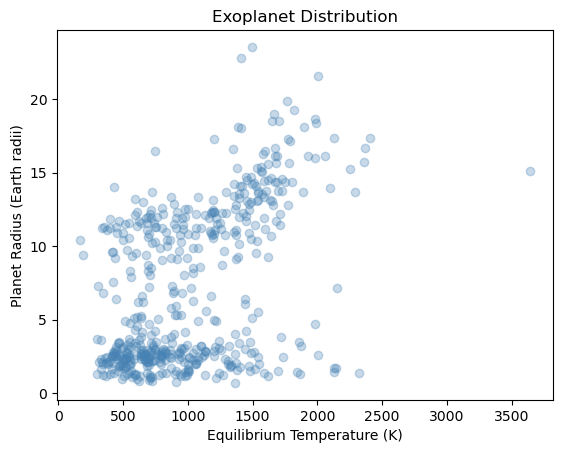

In [27]:
plt.figure()

plt.scatter(
    df_clean["pl_eqt"],
    df_clean["pl_rade"],
    alpha=0.3,
    color="steelblue"
)

plt.xlabel("Equilibrium Temperature (K)")
plt.ylabel("Planet Radius (Earth radii)")
plt.title("Exoplanet Distribution")

plt.show()

## Earth-like vs Other Planets

We compare Earth-like planets with the rest of the dataset.

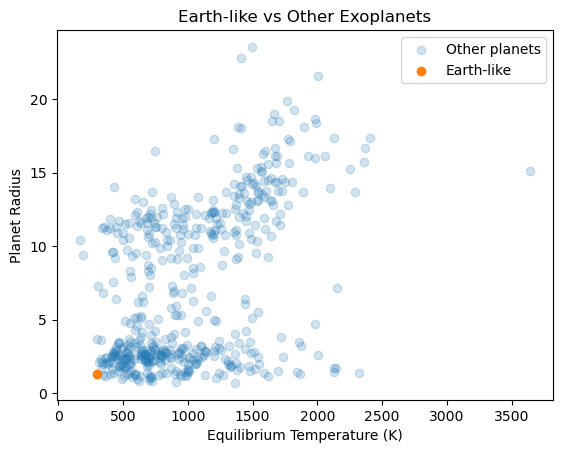

In [28]:
plt.figure()

plt.scatter(
    df_clean[~df_clean["earth_like"]]["pl_eqt"],
    df_clean[~df_clean["earth_like"]]["pl_rade"],
    alpha=0.2,
    label="Other planets"
)

plt.scatter(
    df_clean[df_clean["earth_like"]]["pl_eqt"],
    df_clean[df_clean["earth_like"]]["pl_rade"],
    label="Earth-like"
)

plt.xlabel("Equilibrium Temperature (K)")
plt.ylabel("Planet Radius")
plt.title("Earth-like vs Other Exoplanets")

plt.legend()
plt.show()

## Radius Distribution

We analyze how planet sizes are distributed.

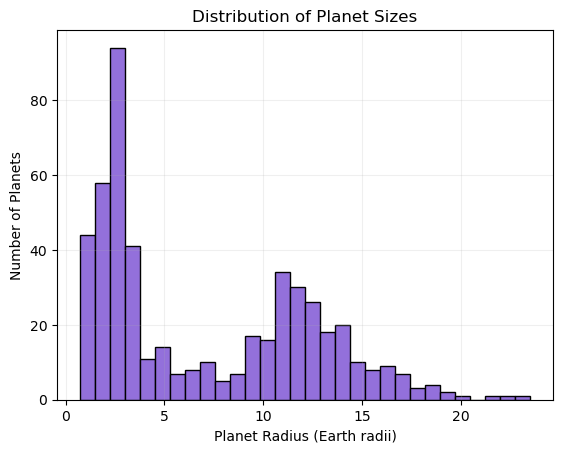

In [30]:
plt.figure()

df_clean["pl_rade"].hist(
    bins=30,
    color="mediumpurple",
    edgecolor="black"
)

plt.xlabel("Planet Radius (Earth radii)")
plt.ylabel("Number of Planets")
plt.title("Distribution of Planet Sizes")

plt.grid(alpha=0.2)

plt.show()

## 1st Conclusion

From our analysis, we observe that most exoplanets in the dataset have radii significantly larger than Earth. The distribution is clearly skewed toward larger planets, with a high concentration between roughly 1 and 4 Earth radii, and another noticeable group around much larger values (above 10 Earth radii). This suggests that large planets, such as gas giants, are more commonly detected.

When looking at the relationship between equilibrium temperature and planet radius, we see that planets are spread across a wide range of temperatures, but there is no strong visible correlation between temperature and size. Most planets cluster at lower radii, while larger planets appear across various temperatures, indicating that size and temperature are relatively independent in this dataset.

Our definition of Earth-like planets (based on radius and temperature constraints) results in only **1 planet out of 507** being classified as Earth-like. This extremely small number highlights two important points: first, Earth-like planets are either rare in the dataset or difficult to detect with current methods; second, our criteria might be quite strict and could be refined in future analysis.

Overall, this initial exploration shows that the dataset is dominated by larger, non-Earth-like planets and that detection bias likely plays a significant role. These observations will guide us in refining our definition of Earth-like planets and exploring more advanced analysis in the next steps.